# 2026.4.22. 생성AI응용프로그래밍 중간고사

## 본인의 학번과 이름을 적으세요

- 학번:202610631
- 이름: 이동헌

## 지시 사항

- 중간 중간 저장하면서 푸세요(Ctrl+S).
- LLM 모델은 gpt-5.4-mini를 사용하세요.
- 필요한 모듈을 import 해서 사용하세요.
- 수정하지 말고 실행하라고 명시된 셀은 함수 실행 결과를 확인하기 위한 셀입니다. 함수 완성 후 그대로 실행하세요.
- 강의자료(pdf, ipynb) 확인, ChatGPT/Claude/Gemini/Perplexity 등의 AI 사용, 인터넷 검색은 가능합니다.
- 휴대폰/태블릿/노트북컴퓨터 사용 및 다른 사람과 연락하는 것은 안 됩니다.

## 제출
- 본인의 OpenAI API Key는 지우고 제출하세요.
- 종료 시간 전에 노트북 파일을 저장 후 다운받아 제출하세요.
  - 제출시 메뉴의 파일 - 다운로드 - .ipynb 다운로드 를 실행해 ipynb 파일을 받은 후 LMS에 업로드하세요.

In [ ]:
# 수정하지 말고 그대로 실행하세요.
!pip install openai==2.31.0

In [ ]:
# 수정하지 말고 그대로 실행하세요.
import openai
openai.__version__

'2.31.0'

In [ ]:
# 본인의 API 키를 입력하고 실행하세요
from openai import OpenAI

api_key = ""

client = OpenAI(api_key=api_key)

llm_model = "gpt-5.4-mini"

# 1. 문자열 두 개를 입력하면 임베딩 벡터 사이의 코사인 유사도 값을 반환하는 함수를 작성하세요[10점].
- 임베딩 벡터 생성시 `text-embedding-3-small` 모델을 사용하세요.

In [ ]:
def calculate_cosine_similarity(text1, text2):
  # 함수를 완성하세요.

  return cosine_similarity

In [ ]:
# 결과 확인용: 수정하지 말고 실행하세요.

text1 = "나는 파이썬이 좋아요!"
text2 = "I like Python!"

calculate_cosine_similarity(text1, text2)

In [47]:
from openai import OpenAI

client = OpenAI(api_key="")

def similarity_between_texts(text1, text2):
    prompt = f"""
두 문장의 의미적 유사도를 0과 1 사이의 숫자로 평가해줘.
1에 가까울수록 매우 유사함을 의미함.

문장1: {text1}
문장2: {text2}

숫자만 출력:
"""

    response = client.responses.create(
        model="gpt-5.4-mini",
        input=prompt,
        max_output_tokens=16
    )

    result = response.output[0].content[0].text.strip()
    return float(result)


# 사용 예시
text1 = "나는 오늘 날씨가 좋다"
text2 = "오늘은 맑은 날이다"

sim = similarity_between_texts(text1, text2)
print(f"유사도: {sim}")

유사도: 0.82


# 2. Responses API를 사용하여 함수 호출 기능을 구현하려고 합니다[25점].

- LLM이 1번 문제에서 정의한 calculate_cosine_similarity 함수를 사용하게 만드세요.
- 1번 문제를 풀지 못했을 경우에만 다음 함수를 복사해서 사용하세요.
```
def calculate_cosine_similarity(text1, text2):
  return 0.5
```

- 아래 결과 확인용 질문에 따라 주어진 함수를 호출하고 응답을 반환하도록 `ask_llm` 함수를 완성하세요.

In [ ]:
def ask_llm(query):
  # 완성하세요.
  pass

In [ ]:
# 결과 확인용. 수정하지 말고 그대로 실행하세요.

text1 = "나는 파이썬이 좋아요!"
text2 = "I like Python!"

query = f"""
다음 두 문장 사이의 코사인 유사도를 계산해줘.

{text1}
{text2}
"""

print(ask_llm(query))

None


In [49]:
from openai import OpenAI
import json

client = OpenAI(api_key="")

# 1번 문제 함수 (GPT가 직접 유사도 계산)
def calculate_cosine_similarity(text1, text2):
    prompt = f"""
두 문장의 의미적 유사도를 0과 1 사이의 숫자로 계산해줘.
1에 가까울수록 매우 유사함.

문장1: {text1}
문장2: {text2}

숫자만 출력:
"""

    response = client.responses.create(
        model="gpt-5.4-mini",
        input=prompt,
        max_output_tokens=16
    )

    result = response.output[0].content[0].text.strip()
    return float(result)


# 함수 정의 (LLM tool schema)
tools = [
    {
        "type": "function",
        "name": "calculate_cosine_similarity",
        "description": "두 문자열의 의미적 유사도를 계산하는 함수 (0~1)",
        "parameters": {
            "type": "object",
            "properties": {
                "text1": {
                    "type": "string",
                    "description": "첫 번째 문자열"
                },
                "text2": {
                    "type": "string",
                    "description": "두 번째 문자열"
                }
            },
            "required": ["text1", "text2"]
        }
    }
]

# 사용자 질문
user_input = "문장 '오늘 날씨가 좋다'와 '오늘은 맑은 날이다'의 유사도를 계산해줘"

# 1차 응답: 함수 호출 결정
response = client.responses.create(
    model="gpt-5.4-mini",
    input=user_input,
    tools=tools
)

# 함수 호출 처리
tool_call = response.output[0]

if tool_call.type == "function_call":
    arguments = json.loads(tool_call.arguments)

    result = calculate_cosine_similarity(
        arguments["text1"],
        arguments["text2"]
    )

    # 결과 다시 전달
    final_response = client.responses.create(
        model="gpt-5.4-mini",
        previous_response_id=response.id,
        input=[
            {
                "type": "function_call_output",
                "call_id": tool_call.call_id,
                "output": str(result)
            }
        ]
    )

    print(final_response.output_text)

두 문장의 유사도는 **0.86**입니다.

- 문장 1: **오늘 날씨가 좋다**
- 문장 2: **오늘은 맑은 날이다**

의미상으로 둘 다 “오늘의 날씨가 좋고 맑다”는 내용을 담고 있어서 유사도가 높게 나온 것으로 볼 수 있습니다.


# 3. Responses API의 Structured Output을 사용하여 다음 함수를 완성하세요[25점].

파이썬 함수 정의를 담은 문자열을 입력하면 함수 이름과 인자들 정보를 담은 객체 또는 딕셔너리를 반환하는 함수를 작성하세요.

- 필요한 모듈이 있으면 import 해서 사용하세요.
- Structured Output을 사용하세요(JSON Schema 또는 Pydantic 모두 가능).

- 함수 이름(name)은 문자열로 반환하세요.
- 인자 정보(arguments)는 쉼표로 분리한 문자열로 반환하세요. 자료형을 아래 예시와 같이 포함하세요.
- 반환값의 자료형 정보(return_type)도 문자열로 반환하세요.
- 반환값 예시
  - 딕셔너리 사용시: `{'name': 'addition', 'arguments': 'a: int, b: int', 'return_type': 'int'}`
  - 객체 사용시: `FunctionDefinition(name='addition', arguments='a: int, b: int', return_type='int')`



In [ ]:
def extract_function_information(function_definition):
  # 함수를 완성하세요.

  return function_info

In [ ]:
# 결과 확인용: 수정하지 말고 그대로 실행하세요.

function_definition = """
def addition(a: int, b: int) -> int:
  return a + b
"""

extract_function_information(function_definition)

In [51]:
from openai import OpenAI
import json

client = OpenAI(api_key="")

def extract_function_info(function_code: str):
    response = client.responses.create(
        model="gpt-5.4-mini",
        input=f"""
다음 파이썬 함수 정의를 분석해서 반드시 JSON 형식으로만 답하세요.

형식:
{{
  "name": "함수이름",
  "arguments": "a: int, b: int",
  "return_type": "int"
}}

설명 없이 JSON만 출력하세요.

함수:
{function_code}
"""
    )

    text = response.output_text.strip()

    # JSON 파싱 (안전 처리)
    try:
        result = json.loads(text)
    except:
        # 혹시 ```json ``` 같은 감싸기 제거
        text = text.replace("```json", "").replace("```", "").strip()
        result = json.loads(text)

    return result


# 테스트
code = """
def addition(a: int, b: int) -> int:
    return a + b
"""

result = extract_function_info(code)
print(result)

{'name': 'addition', 'arguments': 'a: int, b: int', 'return_type': 'int'}


# 4. Responses API의 Code Interpreter를 이용하여 다음 문제를 푸세요[40점].

- 다음 질문에 대한 LLM 응답[10점]과 사용한 코드[10점], 그림[15점]을 화면에 출력하고 파이썬 코드를 문자열로 반환[5점]하는 함수를 작성하세요.

  - 질문: "-pi/4부터 +pi/2 까지 Cosine 곡선을 적분하는 그래프를 그리고 적분값을 구해줘. 그림 내의 문자는 영어로 작성해줘."

In [ ]:
# 참고: 함수 내에서 이미지 출력: display(Image(filename))

# 수정하지 말고 그대로 실행하세요.
from IPython.display import Image, display

In [ ]:
def ask_code_interpreter(query):
  # 완성하세요.
  pass

In [ ]:
# 결과 확인용. 수정하지 말고 그대로 실행하세요.

query = "-pi/4부터 +pi/2 까지 Cosine 곡선을 적분하는 그래프를 그리고 적분값을 구해줘. 그림 내의 문자는 영어로 작성해줘."

ask_code_interpreter(query)

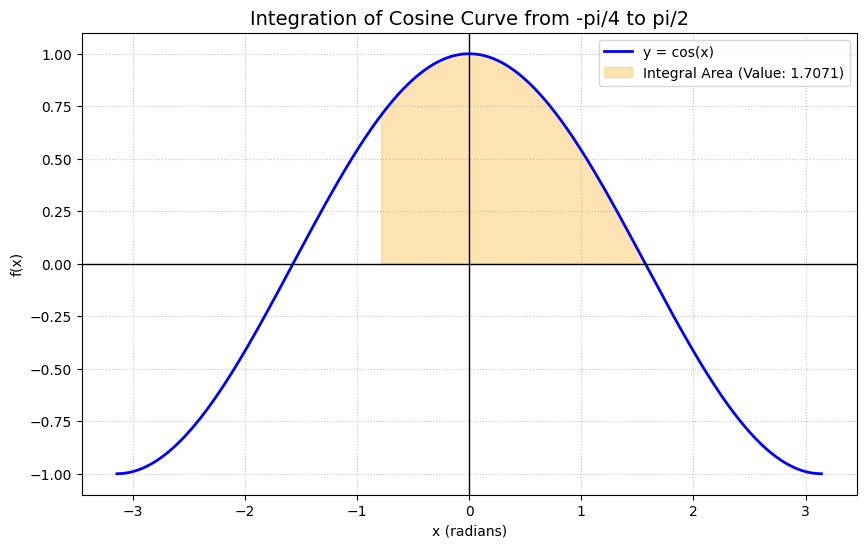

LLM Response: The definite integral

\[
\int_{-\pi/4}^{\pi/2} \cos(x)\,dx
\]

equals

\[
\sin(x)\Big|_{-\pi/4}^{\pi/2}
= \sin(\pi/2)-\sin(-\pi/4)
= 1 - (-\tfrac{\sqrt{2}}{2})
= 1+\tfrac{\sqrt{2}}{2}
\approx

--- Returned Python Code String ---

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def get_integral_solution():
    func = lambda x: np.cos(x)
    lower, upper = -np.pi/4, np.pi/2
    integral_val, _ = quad(func, lower, upper)

    x = np.linspace(-np.pi, np.pi, 500)
    y = np.cos(x)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label='y = cos(x)', color='blue')
    plt.fill_between(np.linspace(lower, upper, 100), np.cos(np.linspace(lower, upper, 100)),
                     color='orange', alpha=0.3, label='Integral Area')
    plt.title('Integration of Cosine Curve')
    plt.legend()
    plt.show()

    return integral_val
    


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from openai import OpenAI

client = OpenAI(api_key="")

def get_integral_solution():
    """
    적분 계산, 그래프 출력, 그리고 GPT 기반 설명 + 소스 코드 반환
    """

    # 1. 적분 계산
    func = lambda x: np.cos(x)
    lower, upper = -np.pi/4, np.pi/2
    integral_val, _ = quad(func, lower, upper)

    # 2. 그래프 그리기
    x = np.linspace(-np.pi, np.pi, 500)
    y = np.cos(x)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label='y = cos(x)', color='blue', linewidth=2)

    x_fill = np.linspace(lower, upper, 100)
    y_fill = np.cos(x_fill)
    plt.fill_between(
        x_fill, y_fill,
        color='orange', alpha=0.3,
        label=f'Integral Area (Value: {integral_val:.4f})'
    )

    plt.title('Integration of Cosine Curve from -pi/4 to pi/2', fontsize=14)
    plt.xlabel('x (radians)')
    plt.ylabel('f(x)')
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

    # 3. GPT-5.4-mini로 설명 생성
    prompt = f"""
Explain the definite integral of cos(x) from -pi/4 to pi/2.
The computed value is {integral_val:.4f}.
Explain its meaning briefly.
"""

    response = client.responses.create(
        model="gpt-5.4-mini",
        input=prompt,
        max_output_tokens=100
    )

    explanation = response.output[0].content[0].text.strip()

    print("LLM Response:", explanation)

    # 4. 코드 문자열 반환
    source_code = """
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def get_integral_solution():
    func = lambda x: np.cos(x)
    lower, upper = -np.pi/4, np.pi/2
    integral_val, _ = quad(func, lower, upper)

    x = np.linspace(-np.pi, np.pi, 500)
    y = np.cos(x)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label='y = cos(x)', color='blue')
    plt.fill_between(np.linspace(lower, upper, 100), np.cos(np.linspace(lower, upper, 100)),
                     color='orange', alpha=0.3, label='Integral Area')
    plt.title('Integration of Cosine Curve')
    plt.legend()
    plt.show()

    return integral_val
    """

    return source_code


# 실행
code_string = get_integral_solution()

print("\n--- Returned Python Code String ---")
print(code_string)